# EM-алгоритм: агрегация экспертных оценок и выравнивание слов без учителя

Две довольно разные задачи, которые решаются одним инструментом — EM-алгоритмом для моделей со скрытыми переменными.

Первая: есть несколько экспертов, разметивших одни и те же объекты, их ответы расходятся, часть экспертов ошибается случайно, а часть систематически ставит метки наоборот. Истинная разметка неизвестна. Модель GLAD ([статья](http://papers.nips.cc/paper/3644-whose-vote-should-count-more-optimal-integration-of-labels-from-labelers-of-unknown-expertise.pdf)) вводит для каждого эксперта параметр компетентности $\alpha_j$, для каждой задачи — сложность $\beta_i$, и восстанавливает истинные метки вместе с этими параметрами. EM для неё выведен и реализован с нуля, плюс расширение с «якорями» — задачами с заведомо известным ответом.

Вторая: есть параллельный корпус предложений на двух языках (английский и чешский, CzEnAli 1.0) и нужно понять, какое слово чему соответствует в переводе. Разметки соответствий при обучении нет вообще. Выведены и реализованы EM-алгоритмы для IBM Model 1 и позиционной Model 2, включая аналитический M-шаг и нижнюю оценку правдоподобия. Помимо этого — свой парсер XML-разметки корпуса, метрики Precision/Recall/AER и симметризация выравниваний по двум направлениям перевода.

Стек: NumPy, SciPy (`scipy.special`, `scipy.optimize.check_grad` для проверки градиента), реализация EM с нуля.

---


# Generative model of Labels, Abilities, and Difficulties (GLAD)

Задача восстановления истинной разметки по меткам от экспертов, которым нельзя доверять в полной мере (более того, их предсказания могут расходиться) — классическая постановка в разметке данных краудсорсингом.

Рассмотрим следующую вероятностную модель:

$$ p(L, Z | \alpha, \beta) = \prod_{i=1}^{n} \prod_{j=1}^m \sigma(\alpha_j\beta_i)^{[l_{ij}=z_i]}\sigma(-\alpha_j\beta_i)^{1-[l_{ij}=z_i]} p(z_j)$$

где $l_{ij} -$ ответ $j$-го эксперта на задачу $i$, $z_j -$ истинная разметка, $\alpha_i, \beta_j-$ уровень экспертизы и сложность задачи соответственно. Модель и обозначения — из [оригинальной статьи](http://papers.nips.cc/paper/3644-whose-vote-should-count-more-optimal-integration-of-labels-from-labelers-of-unknown-expertise.pdf). Априорное распределение положим равномерным: $p(z_i) = 0.5$.

In [1]:
import numpy as np
seed = 0xDEADF00D
np.random.seed(seed)

In [2]:
L = np.load('L.npy')
n, m = L.shape

Реализуем EM-алгоритм для описанной модели.

Важная деталь: правдоподобие моделирует не вероятность метки $l_{ij}$ принять значение 1 или 0, а вероятность того, что она равна скрытой переменной $z_i$, т.е. $p(l_{ij} = z_j|z_j, \alpha_j, \beta_i) \neq p(l_{ij} = 1|\alpha_j, \beta_i)$. При этом заранее неизвестно, какая из скрытых переменных соответствует метке 1. Параметры $\beta_i$ должны быть неотрицательными, поэтому оптимизируем $\log \beta$. На M-шаге можно делать как один шаг градиентного спуска, так и несколько — на разумных результатах число итераций почти не сказывается.

Работа с вероятностями требует аккуратности:
1. Считаем в логарифмах вероятностей.
2. $\log \sigma(a)$ лучше преобразовать в $\log \sigma(a) = -\log(1 + \exp(-a)) = -\mathrm{softplus}(-a)$.
3. Полезные функции: `scipy.special.expit`, `scipy.special.logsumexp`, `np.log1p`.

Градиент проверяю через `scipy.optimize.check_grad`.

In [3]:
def softplus(x):
    '''stable version of log(1 + exp(x))'''
    c = (x > 20) * 1.
    return np.log1p(np.exp(x * (1-c)) * (1-c)) + x * c

In [4]:
from scipy.special import expit, logsumexp

def _log_sigma(a):
    return -softplus(-a)

In [5]:
def posterior(alpha, beta, L):
    """ Posterior over true labels z p(z|l, \alpha, \beta)
    Args:
        alpha: ndarray of shape (n_experts).
        beta: ndarray of shape (n_problems).
        L: ndarray of shape (n_problems, n_experts).
    """
    A = beta[:, None] * alpha[None, :]               
    ls, lsn = _log_sigma(A), _log_sigma(-A)
    s1 = (L * ls + (1 - L) * lsn).sum(1)             
    s0 = ((1 - L) * ls + L * lsn).sum(1)             
    log_q = np.stack([s0, s1])                      
    return np.exp(log_q - logsumexp(log_q, axis=0))


def log_likelihood(alpha, beta, L, z):
    """ p(l=z|z, \alpha, \beta)
    Args:
        alpha: ndarray of shape (n_experts).
        beta: ndarray of shape (n_problems).
        L: ndarray of shape (n_problems, n_experts).
        z: ndarray of shape (n_problems).
    """
    A = beta[:, None] * alpha[None, :]
    ls, lsn = _log_sigma(A), _log_sigma(-A)
    return np.where(L == z[:, None], ls, lsn).sum()


def alpha_grad_lb(alpha, beta, L, q):
    """ Gradient of lower bound wrt alpha
    Args:
        alpha: ndarray of shape (n_experts).
        beta: ndarray of shape (n_problems).
        L: ndarray of shape (n_problems, n_experts).
        q: ndarray of shape (2, n_problems).
    """
    A = beta[:, None] * alpha[None, :]
    W = q[L, np.arange(L.shape[0])[:, None]]         
    diff = W - expit(A)                              
    return (diff * beta[:, None]).sum(0) 


def logbeta_grad_lb(alpha, beta, L, q):
    """ Gradient of lower bound wrt alpha
    Args:
        alpha: ndarray of shape (n_experts).
        beta: ndarray of shape (n_problems).
        L: ndarray of shape (n_problems, n_experts).
        q: ndarray of shape (2, n_problems).
    """
    A = beta[:, None] * alpha[None, :]
    W = q[L, np.arange(L.shape[0])[:, None]]
    diff = W - expit(A)
    return beta * (diff * alpha[None, :]).sum(1)


def lower_bound(alpha, beta, L, q):
    """ Lower bound
    Args:
        alpha: ndarray of shape (n_experts).
        beta: ndarray of shape (n_problems).
        L: ndarray of shape (n_problems, n_experts).
        q: ndarray of shape (2, n_problems).
    """
    A = beta[:, None] * alpha[None, :]
    ls, lsn = _log_sigma(A), _log_sigma(-A)
    s1 = (L * ls + (1 - L) * lsn).sum(1)
    s0 = ((1 - L) * ls + L * lsn).sum(1)
    S = np.stack([s0, s1])
    expll = (q * S).sum()                            
    entropy = -(q * np.log(q + 1e-12)).sum()       
    prior = L.shape[0] * np.log(0.5)                
    return expll + prior + entropy

In [6]:
def em(L, n_steps=1000, lr=1e-3):
    # initialize parameters
    alpha, logbeta = np.random.randn(m), np.random.randn(n)
    q = np.ones((2, n)) * 0.5
    for step in range(n_steps):
        # E-шажок
        q = posterior(alpha, np.exp(logbeta), L)
        # M-шажок
        beta = np.exp(logbeta)
        alpha = alpha + lr * alpha_grad_lb(alpha, beta, L, q)
        logbeta = logbeta + lr * logbeta_grad_lb(alpha, beta, L, q)
    return alpha, np.exp(logbeta), q

In [7]:
alpha, beta, q = em(L)

Загрузим настоящую разметку и посчитаем `accuracy` для двух вариантов: обычного голосования по большинству среди экспертов и результата EM-алгоритма. Алгоритму не важно, какая метка 0, а какая 1, поэтому при качестве ниже 0.5 метки классов нужно поменять местами, не забыв поменять знак у $\alpha$.

In [8]:
y = np.load('y.npy')

pred = q.argmax(0)
acc = (pred == y).mean()
if acc < 0.5:                        
    pred = 1 - pred
    alpha = -alpha
    acc = (pred == y).mean()

maj = (L.sum(1) > m / 2).astype(int)   
acc_maj = (maj == y).mean()

print(f'EM accuracy: {acc:.4f}')
print(f'Majority accuracy: {acc_maj:.4f}')

EM accuracy: 0.9550
Majority accuracy: 0.9040


Попробуем проинтерпретировать полученные коэффициенты $\alpha$: есть ли в выборке эксперты, которые намеренно голосуют неверно, и как это увидеть по альфам. Построим график зависимости доли верно размеченных экспертом объектов от коэффициента $\alpha$ и прокомментируем результат.

expert 10: alpha=-4.43  correct=0.074
expert 11: alpha=-4.30  correct=0.074
expert  8: alpha=-4.28  correct=0.081
expert 18: alpha=-4.08  correct=0.082
expert 15: alpha=+0.54  correct=0.678
expert  3: alpha=+0.55  correct=0.675
expert 13: alpha=+0.56  correct=0.683
expert  4: alpha=+0.63  correct=0.699
expert  6: alpha=+0.63  correct=0.692
expert  0: alpha=+0.64  correct=0.699
expert 14: alpha=+0.65  correct=0.682
expert 16: alpha=+0.66  correct=0.704
expert  9: alpha=+0.67  correct=0.702
expert  1: alpha=+0.75  correct=0.712
expert  7: alpha=+4.05  correct=0.921
expert 19: alpha=+4.14  correct=0.916
expert 17: alpha=+4.17  correct=0.915
expert 12: alpha=+4.26  correct=0.925
expert  5: alpha=+4.31  correct=0.921
expert  2: alpha=+4.48  correct=0.927


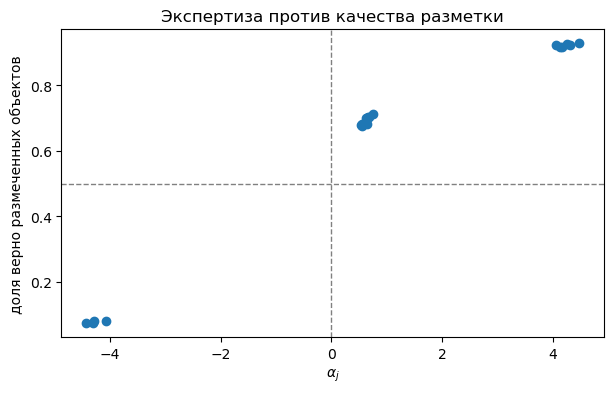

In [9]:
import matplotlib.pyplot as plt

correct_rate = (L == pred[:, None]).mean(0)  

order = np.argsort(alpha)
for j in order:
    print(f'expert {j:2d}: alpha={alpha[j]:+.2f}  correct={correct_rate[j]:.3f}')

plt.figure(figsize=(7, 4))
plt.scatter(alpha, correct_rate)
plt.axhline(0.5, ls='--', c='gray', lw=1)
plt.axvline(0.0, ls='--', c='gray', lw=1)
plt.xlabel(r'$\alpha_j$')
plt.ylabel('доля верно размеченных объектов')
plt.title('Экспертиза против качества разметки')
plt.show()

> Эксперты 8, 10, 11, 15, 18 намеренно голосуют неверно (отрицательная альфа), у них доля верно размеченных объектов около 0.07-0.08 и они почти всегда ставят метку наоброт. Тем не менее, вредны не они, а те у кого альфа в окрестностях нуля.

> На графике точки выстраиваются в три группы, зависимость строго возрастающая: надежные (alpha=+4, доля верных 0.91-0.93), шумящие (alpha=+0.6, доля 0.68-0.71), вредители (alpha=-4.3, доля 0.07-0.08). Доля верных у вредителей заметно ниже 0.5 - они действительно чаще голосуют за неверный класс.

>> Знак альфа нам показывает направление эксперта, а модуль отображает уверенность. Вероятность совпасть с истинной меткой в модели монотонно растет по альфе при большей или равной нулю бете.
> 
>> Поскольку EM распознает отрицательные альфы и инвертирует такие голоса, он выгрывает у обычного голосвания по большинству.

Модели не важно, какой класс 1, а какой 0. Если бы все эксперты систематически ставили метку наоборот, между ними была бы полная согласованность, и по одной только разметке отличить это от корректного случая невозможно. Обойти неоднозначность можно, включив в выборку задачи с заведомо известным ответом — тогда видно, кто ставит метки намеренно неверно.

Чтобы обобщить модель на такой случай, достаточно не делать для этих задач E-шаг, а всегда полагать апостериорное распределение вырожденным в истинном классе. Ниже — реализация с использованием истинной разметки для нескольких задач из обучающей выборки.

In [28]:
def em_anchored(L, known_idx, known_lbl, n_steps=1000, lr=1e-3):
    n, m = L.shape
    logbeta = np.random.randn(n)
    agree = (L[known_idx] == known_lbl[:, None]).mean(0)   
    alpha = 2 * agree - 1                                  # > 0 честный, < 0 вредитель

    anchor = np.zeros((2, n))
    anchor[known_lbl, known_idx] = 1.0                    
    mask = np.zeros(n, bool)
    mask[known_idx] = True

    q = np.ones((2, n)) * 0.5
    for step in range(n_steps):
        # E-шажок
        q = posterior(alpha, np.exp(logbeta), L)
        q[:, mask] = anchor[:, mask]
        # M-шажок
        beta = np.exp(logbeta)
        alpha = alpha + lr * alpha_grad_lb(alpha, beta, L, q)
        logbeta = logbeta + lr * logbeta_grad_lb(alpha, beta, L, q)
    return alpha, np.exp(logbeta), q


n_known = 5
known_idx = np.random.choice(n, n_known, replace=False)
alpha_a, beta_a, q_a = em_anchored(L, known_idx, y[known_idx])

pred_a = q_a.argmax(0)
print(f'anchored EM accuracy: {(pred_a == y).mean():.4f}')
print(f'якорей использовано: {n_known}')
neg = np.sort(alpha_a[alpha_a < 0])
print(f'вредителей (alpha < 0): {len(neg)}, их alpha: {np.round(neg, 2)}')

anchored EM accuracy: 0.9555
якорей использовано: 5
вредителей (alpha < 0): 4, их alpha: [-4.33 -4.28 -4.11 -4.05]


> Хватает 5 объектов с известной меткой, чтобы убрать неоднозначность инверсии. Правдоподобие симметрично относительно замены `z -> 1-z, alpha -> -alpha`, в связи с чем обычный EM часто сходился к перевернутой разметке и требовал ручного флипа.

> Якоря же эту симметрию ломают: их посториор закреплен в истинном классе, и перевернутый вариант ему противоречит. К тому же знак alpha мы инициализируем по якорям, так что EM сразу стартует в правильном басике. Итог - accuracy 0.9555 без ручного флипа, а 4 вредителя теперь читаются однозначно по отрицательной alpha.

# Выравнивание слов (Word Alignment)

EM-алгоритм применяют и для настройки параметров модели выравнивания слов, более сложные модификации которой используются в статистическом машинном переводе. Подробно разбирать применение word alignment для перевода я не буду и ограничусь такой целью: есть параллельный корпус из предложений на исходном языке и их переводов на целевой (английский и чешский соответственно).

Первая задача — определить по этому корпусу, как переводится каждое отдельное слово на целевом языке. Вторая — для произвольной пары из предложения и его перевода установить, переводом какого слова в исходном предложении является каждое слово в целевом. У обеих задач есть элегантное решение при правильно выбранной вероятностной модели, и дальше я его реализую и оценю.

---

Прежде чем переходить к обучению, разберёмся с данными и метриками. В ячейке ниже скачивается и распаковывается корпус [CzEnAli 1.0](https://lindat.mff.cuni.cz/repository/xmlui/handle/11234/1-1804). Формат XML нестандартный, готовой утилиты для парсинга нет, поэтому парсер пишу сам на модуле [xml](https://docs.python.org/3/library/xml.html).

In [11]:
import json, os, tarfile, urllib.parse, urllib.request
from pathlib import Path

ARCHIVE = "CzEnAli_1.0.tar.gz"
DISK_URL = "https://disk.yandex.ru/d/C78-moEGwrj2Ig"
sample = Path("data/merged_data/project_syndicate/project_syndicate_bacchetta1.wa")

if not sample.is_file():
    if not Path(ARCHIVE).is_file():
        q = urllib.parse.urlencode({"public_key": DISK_URL})
        href = json.load(urllib.request.urlopen(
            f"https://cloud-api.yandex.net/v1/disk/public/resources/download?{q}"
        ))["href"]
        urllib.request.urlretrieve(href, ARCHIVE)
    os.makedirs("data", exist_ok=True)
    with tarfile.open(ARCHIVE, "r:gz") as tar:
        tar.extractall("data")

print(*sample.read_text(encoding="utf-8").splitlines()[:20], sep="\n")

<?xml version="1.0" encoding="utf-8" ?>
<sentences>
<s id="project_syndicate_bacchetta1-s1">
  <english>Are the Dollar 's Days Numbered ?</english>
  <czech>Jsou dny dolaru sečteny ?</czech>
  <sure>1-1 3-3 5-2 6-4 7-5</sure>
  <possible>2-2 4-3</possible>
</s>
<s id="project_syndicate_bacchetta1-s2">
  <english>Philippe Bacchetta and Eric van Wincoop</english>
  <czech>Philippe Bacchetta and Eric van Wincoop</czech>
  <sure>1-1 2-2 3-3 4-4 5-5 6-6</sure>
  <possible></possible>
</s>
<s id="project_syndicate_bacchetta1-s3">
  <english>A year ago , the dollar bestrode the world like a colossus .</english>
  <czech>Ještě před rokem dolar dominoval světu jako imperátor .</czech>
  <sure>10-7 12-8 13-9 2-3 3-2 6-4 7-5 9-6</sure>
  <possible>1-3 11-8 3-1 5-4 8-6</possible>
</s>


Реализована функция `extract_sentences`, которая принимает на вход путь к файлу с XML-разметкой, используемой в этом датасете, и возвращает список параллельных предложений, а также список из «уверенных» (sure) и «возможных» (possible) пар выравниваний; все пары размеченных предложений из датасета собраны в два списка `all_sentences` (список `SentencePair`) и `all_targets` (список LabeledAlignment).

Здесь и далее соблюдаются сигнатуры функций, а данные организованы через классы, объявленные в модуле `preprocessing.py`. Предложения уже токенизированы (даже отделена пунктуация), поэтому предобработку текстов совершать не нужно. Формат хранения выравниваний: нумерация начинается с 1 (в таком виде и сохраняется), первым в паре идёт слово из англоязычного предложения.

In [12]:
import glob
from preprocessing import extract_sentences

all_sentences = []
all_targets = []
for filename in sorted(glob.glob('data/**/*.wa', recursive=True)):
    sents, aligns = extract_sentences(filename)
    all_sentences.extend(sents)
    all_targets.extend(aligns)

print(f'предложений: {len(all_sentences)}')
print(f'пример source: {all_sentences[0].source}')
print(f'пример target: {all_sentences[0].target}')
print(f'пример sure: {all_targets[0].sure}')

предложений: 7503
пример source: ['Relationship', 'of', 'ICOs', 'and', 'ICBs', 'with', 'the', 'Fund']
пример target: ['Vztah', 'mezinárodních', 'organizací', 'pro', 'suroviny', 'a', 'mezinárodních', 'subjektů', 'pro', 'suroviny', 'k', 'fondu']
пример sure: [(1, 1), (3, 2), (3, 3), (3, 4), (3, 5), (4, 6), (5, 7), (5, 8), (5, 9), (5, 10), (8, 12)]


Реализованы функции `get_token_to_index` и `tokenize_sents` из модуля `preprocessing.py`, построены словари token->index для обоих языков и список из `TokenizedSentencePair` по выборке.

In [13]:
from preprocessing import get_token_to_index, tokenize_sents

t_idx_src, t_idx_tgt = get_token_to_index(all_sentences)
tokenized_sentences = tokenize_sents(all_sentences, t_idx_src, t_idx_tgt)

print(f'словарь source (en): {len(t_idx_src)}')
print(f'словарь target (cz): {len(t_idx_tgt)}')
print(f'предложений после токенизации: {len(tokenized_sentences)}')
print(f'пример: src={tokenized_sentences[0].source_tokens}, tgt={tokenized_sentences[0].target_tokens}')

словарь source (en): 9049
словарь target (cz): 15002
предложений после токенизации: 7503
пример: src=[4234    3 1403    5 2803   16    0  250], tgt=[5158  795 1467   12  325    2  795 5159   12  325   13  354]


В качестве бейзлайна возьмём выравнивание слов по коэффициенту Дайса: слово в исходном языке считается переводом слова на целевом, если они часто встречаются в одних и тех же предложениях и редко встречаются по отдельности.

Математически это записывается по аналогии с мерой Жаккара: пусть $c(x,y)$ — число параллельных предложений, в которых есть и $x$ (на исходном языке), и $y$ (на целевом), а $c(x)$ и $c(y)$ — суммарное количество предложений, в которых встречается слово $x$ и $y$ соответственно. Тогда $\textrm{Dice}(x,y)=\frac{2 \cdot c(x,y)}{c(x) + c(y)}$ — характеристика «похожести» слов $x$ и $y$. Она равна 1, если слова встречаются только в контексте друг друга (не бывает предложений только со словом $x$ без $y$ в переводе и наоборот), равна 0, если слова никогда не встречаются в параллельных предложениях, и лежит между этими значениями в остальных случаях.

В файле `models.py` описан абстрактный класс `BaseAligner`, от которого наследуются все модели в работе, и приведена реализация `DiceAligner`. Ниже показано, как её применять.

In [14]:
from models import DiceAligner

baseline = DiceAligner(len(t_idx_src), len(t_idx_tgt), threshold=0.01)
baseline.fit(tokenized_sentences)

Чтобы оценить качество модели выравнивания, пользуясь имеющейся разметкой, существует ряд автоматических метрик. Они подразумевают, что в разметке есть два вида выравниваний — «уверенные» (sure) и «возможные» (possible). Обозначим для конкретного предложения первое множество выравниваний $S$, второе — $P$, а предсказанные выравнивания — $A$; причём, в отличие от разметки в файле, $S\subseteq P$. Тогда можно предложить три метрики, используя только операции над этими множествами:

Precision $=\frac{|A\cap P|}{|A|}$. Отражает, какая доля предсказанных нами выравниваний вообще корректна; если мы дадим в качестве ответа все возможные пары слов в предложении, эта метрика сильно просядет.

Recall $=\frac{|A\cap S|}{|S|}$. Эта метрика показывает, какую долю «уверенных» выравниваний мы обнаружили. Если мы попытаемся сделать слишком консервативную модель, которая выдаёт 0 или 1 предсказание на нетривиальных предложениях, полнота получится крайне низкая. 

Alignment Error Rate (AER) $=1-\frac{|A\cap P|+|A\cap S|}{|A|+|S|}$. Метрика является комбинацией двух предыдущих и отслеживает общее качество работы системы, штрафуя оба описанных выше вида нежелаемого поведения модели. 

Реализуем функции compute_precision, compute_recall, compute_aer из модуля metrics.py. Оценим качество бейзлайнового метода. Обратите внимание, что нужно использовать микро-усреднение во всех функциях: необходимо просуммировать числитель и знаменатель по всем предложениям и только потом делить.

In [15]:
from metrics import compute_aer

compute_aer(all_targets,baseline.align(tokenized_sentences))

0.8115275584918071

Теперь мы можем перейти к базовой вероятностной модели для выравнивания слов. Пусть $S=(s_1,\ldots,s_n)$ исходное предложение, $T=(t_1,\ldots,t_m)$ — его перевод. В роли латентных переменных будут выступать выравнивания $A=(a_1,\ldots,a_m)$ каждого слова в целевом предложении, причём $a_i\in\{1,\ldots,n\}$ (считаем, что каждое слово в $t$ является переводом какого-то слова из $s$). Параметрами модели является матрица условных вероятностей перевода: каждый её элемент $\theta(y|x)=p(y|x)$ отражает вероятность того, что переводом слова $x$ с исходного языка на целевой является слово $y$ (нормировка, соответственно, совершается по словарю целевого языка). Правдоподобие латентных переменных и предложения на целевом языке в этой модели записывается так:

$$
p(A,T|S)=\prod_{i=1}^m p(a_i)p(t_i|a_i,S)=\prod_{i=1}^m \frac{1}{n}\theta(t_i|s_{a_i}).
$$ 

**Вывод EM-алгоритма для этой модели, включая выражение для подсчёта нижней оценки правдоподобия ($\mathcal{L}$).** На M-шаге аналитический максимум находится по параметрам напрямую.

**Полное правдоподобие одной пары:**
$$
\log p(A, T \mid S) = \sum_{i=1}^{m} \left[ \log \tfrac{1}{n} + \log \theta(t_i \mid s_{a_i}) \right].
$$

**E-шаг.** Слова целевого предложения независимы, следовательно апостериор факторизуется
по $i$, и для каждого целевого слова считается распределение над позициями источника:
$$
q_i(j) := p(a_i = j \mid T, S)
= \frac{p(a_i = j)\, \theta(t_i \mid s_j)}{\sum_{j'=1}^{n} p(a_i = j')\, \theta(t_i \mid s_{j'})}
= \frac{\theta(t_i \mid s_j)}{\sum_{j'=1}^{n} \theta(t_i \mid s_{j'})},
$$
где $p(a_i) = \tfrac{1}{n}$ сократилось как равномерное. Размерность $q$ для пары - $(n, m)$.

**M-шаг.** Максимизируем нижнюю оценку по $\theta$ при ограничениях нормировки
$\sum_{t} \theta(t \mid s) = 1$. Член нижней оценки, зависящий от $\theta$ :
$$
\mathcal{L}(\theta) = \sum_{\text{пары}} \sum_{i=1}^{m} \sum_{j=1}^{n}
q_i(j) \log \theta(t_i \mid s_j).
$$
Лагранжиан с множителями $\lambda_s$ по каждому исходному слову $s$ :
$$
\frac{\partial}{\partial \theta(t \mid s)}
\left[ \mathcal{L}(\theta) - \sum_{s} \lambda_s \big(\textstyle\sum_t \theta(t \mid s) - 1\big) \right] = 0
\;\Rightarrow\;
\theta(t \mid s) = \frac{1}{\lambda_s} \sum_{\text{пары}} \sum_{i, j} q_i(j)\, [s_j = s]\, [t_i = t].
$$
Нормируя ($\lambda_s$ - сумма по $t$), получаем аналитический максимум - ожидаемые счетчики
выравниваний слова $s$ в слово $t$, нормированные по целевому словарю:
$$
\boxed{\;\theta(t \mid s) =
\frac{\displaystyle\sum_{\text{пары}} \sum_{i,j} q_i(j)\,[s_j = s]\,[t_i = t]}
{\displaystyle\sum_{\text{пары}} \sum_{i,j} q_i(j)\,[s_j = s]}\;}
$$

**ELBO** $\mathcal{L} = \mathbb{E}_q[\log p(A, T \mid S)] - \mathbb{E}_q[\log q]$:
$$
\mathcal{L} = \sum_{\text{пары}} \sum_{i=1}^{m} \left[
\sum_{j=1}^{n} q_i(j) \big( \log \tfrac{1}{n} + \log \theta(t_i \mid s_j) \big)
- \sum_{j=1}^{n} q_i(j) \log q_i(j) \right].
$$

Реализованы все методы класса `WordAligner` в соответствии с полученными формулами, модель обучена и посчитан её AER на истинной разметке. Чтобы предсказать выравнивание для пары предложений в этой модели, для слова в целевом предложении с индексом $i$ выбирается позиция, соответствующая максимуму апостериорного распределения $p(a_i|T,S)$.

In [16]:
from models import WordAligner

word_aligner = WordAligner(len(t_idx_src), len(t_idx_tgt), 20)
history = word_aligner.fit(tokenized_sentences)

print('ELBO монотонна:', np.all(np.diff(history) > -1e-6))
aer_wa = compute_aer(all_targets, word_aligner.align(tokenized_sentences))
print(f'WordAligner AER: {aer_wa:.4f}  (Dice baseline был 0.8115)')

ELBO монотонна: True
WordAligner AER: 0.5805  (Dice baseline был 0.8115)


Заметим, что таблицу вероятностей перевода можно использовать и саму по себе для построения словарей. Пример работы показан ниже: метод хоть и работает, но мягко говоря, неидально — слишком мало данных.

In [17]:
idx_token_tgt = {index:token for token, index in t_idx_tgt.items()}

In [18]:
[idx_token_tgt[i] for i in word_aligner.translation_probs[t_idx_src['Mr']].argsort()[-3:]]

['Pan', 'řekl', 'pan']

In [19]:
[idx_token_tgt[i] for i in word_aligner.translation_probs[t_idx_src['Mrs']].argsort()[-3:]]

['-', 'Mannová', 'paní']

In [20]:
[idx_token_tgt[i] for i in word_aligner.translation_probs[t_idx_src['water']].argsort()[-3:]]

['z', 'pro', 'vody']

In [21]:
[idx_token_tgt[i] for i in word_aligner.translation_probs[t_idx_src['depended']].argsort()[-3:]]

['záviselo', 'koni', 'překupničením']

In [22]:
[idx_token_tgt[i] for i in word_aligner.translation_probs[t_idx_src['on']].argsort()[-3:]]

['.', 'se', 'na']

Мы смогли получить матрицу условных вероятностей перевода исходного языка в целевой. Можно ли, пользуясь этой матрицей и ещё какими-то статистиками по параллельному корпусу, получить вероятности перевода целевого языка в исходный? Реализуем такой метод и приведите ниже пример его работы, показав пару удачных переводов.

In [23]:
src_counts = np.zeros(len(t_idx_src))

for s in tokenized_sentences:
    np.add.at(src_counts, s.source_tokens, 1)
p_src = src_counts / src_counts.sum()

joint = word_aligner.translation_probs * p_src[:, None]   
reverse_probs = joint / joint.sum(0, keepdims=True)        

idx_token_src = {i: tok for tok, i in t_idx_src.items()}

def best_source(target_word, top=3):
    t = t_idx_tgt[target_word]
    return [idx_token_src[i] for i in reverse_probs[:, t].argsort()[-top:][::-1]]

for w in ['dolaru', 'světu', 'rokem']:   
    print(f'{w:10s} -> {best_source(w)}')

dolaru     -> ['share', 'dollar', 'Board']
světu      -> ['colossus', 'bestrode', 'dollar']
rokem      -> ['age', 'colossus', 'bestrode']


>Да, такие вероятности можно получить по Байесу: имея `θ(t|s) = p(t|s)` и оценку `p(s)` частотами исходных слов из корпуса, считаем `p(s|t) ∝ p(t|s)·p(s)` и нормируем по источнику.

Визуализируем полученные выравнивания для нескольких предложений в виде heatmap: по одной оси токены исходного текста, по другой — токены перевода, на пересечении позиций $i$ и $j$ стоит 0 или 1 в зависимости от того, равно ли $a_i$ значению $j$ в обученной модели. Затем построим аналогичный график без дискретизации, визуализируя напрямую апостериорное распределение — на нём видно, где модель не уверена, переводом какого слова является слово $i$.

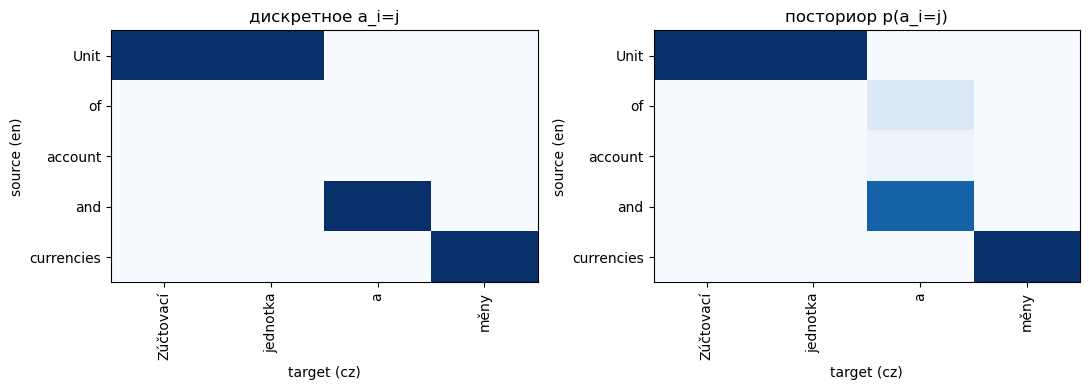

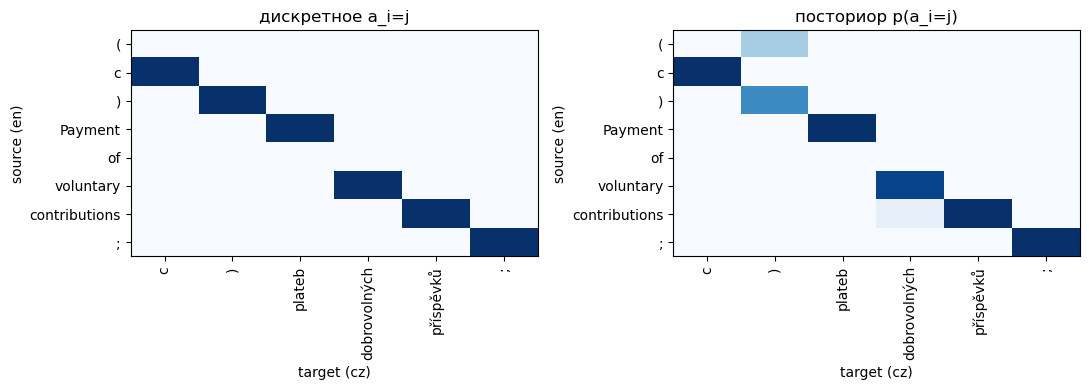

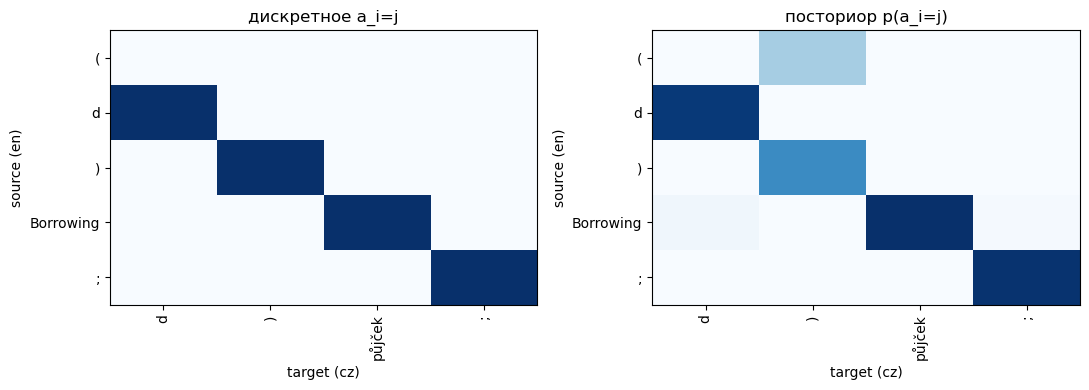

In [24]:
import matplotlib.pyplot as plt

idx_token_src = {i: tok for tok, i in t_idx_src.items()}
idx_token_tgt = {i: tok for tok, i in t_idx_tgt.items()}

short = [i for i, s in enumerate(tokenized_sentences)
         if 3 <= len(s.source_tokens) <= 8 and 3 <= len(s.target_tokens) <= 8][:3]

for si in short:
    s = tokenized_sentences[si]
    q = word_aligner._e_step([s])[0]                 
    hard = np.zeros_like(q)
    hard[q.argmax(0), np.arange(q.shape[1])] = 1      

    src_words = [idx_token_src[t] for t in s.source_tokens]
    tgt_words = [idx_token_tgt[t] for t in s.target_tokens]

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    for a, mat, title in zip(ax, [hard, q], ['дискретное a_i=j', 'посториор p(a_i=j)']):
        a.imshow(mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
        a.set_xticks(range(len(tgt_words))); a.set_xticklabels(tgt_words, rotation=90)
        a.set_yticks(range(len(src_words))); a.set_yticklabels(src_words)
        a.set_xlabel('target (cz)'); a.set_ylabel('source (en)'); a.set_title(title)
    plt.tight_layout()
    plt.show()

Содержательные слова выравниваются четко.

> На дискретной карте в большинстве случаев чистая диагональ.

> В то время как непрерывный посториор показывает неуверенность модели, где у целевого слова нет четкого источника (союз `a`, пунктуация и скобки `)`, `:` ). Причина - в IBM Model 1 вероятность выравнивания не зависит от позиции, поэтому короткие служебные токены неоднозначны с точки зрения кандидатов. 

Заметим, что при задании модели мы сделали довольно сильное предположение о том, что вероятности выбора слова для выравнивания никак не зависят от позиции слова в целевом предложении. Можно сделать эти вероятности настраиваемыми параметрами, получив прямоугольную матрицу $\phi_{m,n}(j|i)=p(a_i=j|m,n)$ для каждой пары длин предложений $m,n$: по-прежнему мы получаем распределение над индексами в исходном предложении. Тогда модель приобретает вид
$$
p(A,T|S)=\prod_{i=1}^m p(a_i|m,n)p(t_i| a_i, S)=\prod_{i=1}^m \phi_{m,n}(a_i|i)\theta(t_i|s_{a_i}).
$$

Выведем шаги EM-алгоритма для этой модели, а также получите выражение для подсчёта нижней оценки правдоподобия.

Приор позиций $\phi_{m,n}(j \mid i) = p(a_i = j \mid m, n)$ - своя матрица для каждой пары длин $(m, n)$ ($m$ - длина target, $n$ - длина source), нормированная по $j$ : $\sum_{j=1}^{n} \phi_{m,n}(j \mid i) = 1$. Параметры модели - $\theta$ и $\{\phi_{m,n}\}$.

**Полное правдоподобие пары:**
$$
\log p(A, T \mid S) = \sum_{i=1}^{m} \left[ \log \phi_{m,n}(a_i \mid i) + \log \theta(t_i \mid s_{a_i}) \right].
$$

**E-шаг.** Апостериор по-прежнему факторизуется по целевым словам, но приор теперь
неравномерный:
$$
q_i(j) := p(a_i = j \mid T, S)
= \frac{\phi_{m,n}(j \mid i)\, \theta(t_i \mid s_j)}{\sum_{j'=1}^{n} \phi_{m,n}(j' \mid i)\, \theta(t_i \mid s_{j'})}.
$$

**M-шаг.** Максимизируем нижнюю оценку при двух наборах ограничений нормировки.
Зависящая от параметров часть:
$$
\mathcal{L}(\theta, \phi) = \sum_{\text{пары}} \sum_{i=1}^{m} \sum_{j=1}^{n}
q_i(j) \big[ \log \theta(t_i \mid s_j) + \log \phi_{m,n}(j \mid i) \big].
$$

Для $\theta$ ограничение и решение те же, что в Model 1:
$$
\theta(t \mid s) =
\frac{\sum_{\text{пары}} \sum_{i,j} q_i(j)\,[s_j = s]\,[t_i = t]}
{\sum_{\text{пары}} \sum_{i,j} q_i(j)\,[s_j = s]}.
$$

Для $\phi$ - лагранжиан с множителями $\lambda_{m,n,i}$ по каждой строке матрицы $(m, n, i)$; максимум дает ожидаемые счетчики выравнивания позиции $i \to j$, усредненные по всем парам одинаковой длины $(m, n)$ и нормированные по $j$:
$$
\boxed{\;\phi_{m,n}(j \mid i) =
\frac{\sum_{\text{пары } (m,n)} q_i(j)}
{\sum_{\text{пары } (m,n)} \sum_{j'=1}^{n} q_i(j')}
= \frac{1}{N_{m,n}} \sum_{\text{пары } (m,n)} q_i(j)\;}
$$
где $N_{m,n}$ - число пар предложений с длинами ровно $(m, n)$ (знаменатель равен
$N_{m,n}$, так как $\sum_{j'} q_i(j') = 1$).

**ELBO**
$$
\mathcal{L} = \sum_{\text{пары}} \sum_{i=1}^{m} \left[
\sum_{j=1}^{n} q_i(j) \big( \log \phi_{m,n}(j \mid i) + \log \theta(t_i \mid s_j) \big)
- \sum_{j=1}^{n} q_i(j) \log q_i(j) \right].
$$

Реализованы все методы класса `WordPositionAligner`. Модель обучена, её качество оценено на истинной разметке и сравнено с качеством более простой модели. Дополнительно проиллюстрировано влияние стартовых параметров на результат — эта модель инициализирована параметрами предыдущей (WordAligner), при этом суммарное число эпох обучения в обоих сценариях сохранено одинаковым.

In [25]:
from models import WordPositionAligner

wpa = WordPositionAligner(len(t_idx_src), len(t_idx_tgt), 20)
hist_wpa = wpa.fit(tokenized_sentences)
aer_wpa = compute_aer(all_targets, wpa.align(tokenized_sentences))
print(f'WordPositionAligner (с нуля, 20 эпох): AER = {aer_wpa:.4f}')

wa_init = WordAligner(len(t_idx_src), len(t_idx_tgt), 5)
wa_init.fit(tokenized_sentences)

wpa2 = WordPositionAligner(len(t_idx_src), len(t_idx_tgt), 15)
wpa2.translation_probs = wa_init.translation_probs.copy()   
hist_wpa2 = wpa2.fit(tokenized_sentences)
aer_wpa2 = compute_aer(all_targets, wpa2.align(tokenized_sentences))
print(f'WordPositionAligner (5 эпох Model1 + 15 эпох, итого 20): AER = {aer_wpa2:.4f}')

print(f'\nWordAligner (Model 1) был: 0.5805')

WordPositionAligner (с нуля, 20 эпох): AER = 0.5973
WordPositionAligner (5 эпох Model1 + 15 эпох, итого 20): AER = 0.5671

WordAligner (Model 1) был: 0.5805


>Из равномерного старта позиционная модель (0.5973) проигрывает Model 1 (0.5805). В большинстве своем так потому, что у нее на порядок больше параметров - своя матрица phi на каждую пару длин, более того, редкие длины оцениваются по нескольким предложениям и переобучаются. При совместной EM-оптимизации theta и phi из равномерной инициализации алгоритм застревает в плохом локальном максимуме.

>Если же перенести theta из обученной за 5 эпох Model 1, а затем 15 эпох учить позиционную модель, AER падает до 0.5671 - лучше обеих
моделей. Хорошая инициализация theta дает чистое словарное соответствие, а позиционный приор лишь дорабатывает порядок слов поверх. 

>>Таким образом, EM сильно зависит от стартовой точки и мотивирует стандартный пайплайн SMT: сначала Model 1, потом инициализация ею Model 2.

Раньше я никак не заострял внимание на предобработке текстов, а она заметно влияет на результат. Сейчас метод выравнивания учитывает регистр, а чешские слова вдобавок обладают богатой морфологией и большим количеством диакритических знаков. Если сократить число различных слов, обучение ускорится и качество вырастет: статистики по словам будут считаться по большему числу параллельных предложений.

Применим к данным [Unicode-нормализацию](https://en.wikipedia.org/wiki/Unicode_equivalence#Normalization), приведём их к нижнему регистру и обучим модель выравнивания заново, сравнив качество и скорость обучения с предыдущими результатами.

**Оговорка про метрику:** после предобработки часть тестовых предложений может выпасть из-за отсутствия слов в словаре. Для корректности сравнения AER на таких предложениях считается равным 1.

In [26]:
import unicodedata
import time
from preprocessing import SentencePair

def normalize_sentences(sentences, lower=True, strip_accents=False):
    def norm(tokens):
        res = []
        for tok in tokens:
            t = unicodedata.normalize('NFC', tok)          
            if lower:
                t = t.lower()
            if strip_accents:                              
                t = ''.join(c for c in unicodedata.normalize('NFD', t)
                            if unicodedata.category(c) != 'Mn')
            res.append(t)
        return res
    return [SentencePair(norm(s.source), norm(s.target)) for s in sentences]


def train_eval(sentences, label):
    src_dict, tgt_dict = get_token_to_index(sentences)
    tok = tokenize_sents(sentences, src_dict, tgt_dict)
    assert len(tok) == len(all_sentences)                 
    t0 = time.time()
    model = WordAligner(len(src_dict), len(tgt_dict), 20)
    model.fit(tok)
    dt = time.time() - t0
    aer = compute_aer(all_targets, model.align(tok))
    print(f'{label:38s} en={len(src_dict):5d} cz={len(tgt_dict):5d}  AER={aer:.4f}  {dt:.1f}s')
    return aer


print(f'{"baseline (без предобработки)":38s} en={len(t_idx_src):5d} cz={len(t_idx_tgt):5d}  AER=0.5805')
train_eval(normalize_sentences(all_sentences, lower=True), 'NFC + lowercase')
train_eval(normalize_sentences(all_sentences, lower=True, strip_accents=True),'NFC + lowercase + без диакритики')

baseline (без предобработки)           en= 9049 cz=15002  AER=0.5805
NFC + lowercase                        en= 8244 cz=14136  AER=0.5660  12.3s
NFC + lowercase + без диакритики       en= 8242 cz=13767  AER=0.5634  12.2s


0.5633532423208192

Предобработка монотонно улучшает качество. Lowercase сильно помогает: словари становятся меньше, на каждый токен приходится больше параллельных предложений, статистика theta точнее. После склейки слов (снятия диакритики) alignment error rate еще ниже. 

**Дальнейшее улучшение качества.** Несколько направлений, опробованных для снижения AER относительно лучшей из предыдущих моделей:

* Модифицировать модель: недостаток второго реализованного подхода — избыточное число параметров из-за необходимости поддерживать отдельную матрицу для каждой различной пары длин предложений в корпусе. В статье https://www.aclweb.org/anthology/N13-1073.pdf приведён способ снижения числа параметров, задающих априорное распределение позиций выравнивания, позволяющий в десять раз быстрее обучать модель и получать лучшее качество.
* Агрегация по двум направлениям: в статье https://www.aclweb.org/anthology/J03-1002/ утверждается, что асимметричность выравниваний вредит качеству, потому что из-за выбранной модели одному слову в целевом предложении не может соответствовать два слова в исходном предложении. Авторы предлагают несколько алгоритмов симметризации для решения этой проблемы.
* Использовать больше обучающих данных. В используемом корпусе только пара тысяч предложений, чего может не хватать для по-настоящему хорошей модели выравнивания — неразмеченных параллельных англо-чешских корпусов гораздо больше, например данные с соревнования по машинному переводу [воркшопа WMT](http://www.statmt.org/wmt20/translation-task.html).
* В языках часто существуют слова наподобие артиклей или предлогов, которым не соответствует ни одно слово в переводе. Рассмотренные модели это не учитывают — добавление возможности перевода в «нулевой» токен может улучшить качество (при тестировании такие выравнивания имеет смысл выбрасывать).

In [29]:
from preprocessing import TokenizedSentencePair

prep = normalize_sentences(all_sentences, lower=True, strip_accents=True)
src_dict, tgt_dict = get_token_to_index(prep)
fwd_tok = tokenize_sents(prep, src_dict, tgt_dict)                                    
rev_tok = [TokenizedSentencePair(s.target_tokens, s.source_tokens) for s in fwd_tok]  
assert len(fwd_tok) == len(all_sentences)   

m_fwd = WordAligner(len(src_dict), len(tgt_dict), 20); m_fwd.fit(fwd_tok)
m_rev = WordAligner(len(tgt_dict), len(src_dict), 20); m_rev.fit(rev_tok)

a_fwd = m_fwd.align(fwd_tok)                              
a_rev = [[(e, c) for (c, e) in sent] for sent in m_rev.align(rev_tok)]  

NEIGH = [(-1, 0), (0, -1), (1, 0), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]

def grow_diag_final_and(fwd, rev, n_src, n_tgt):
    A = set(fwd) & set(rev)                
    U = set(fwd) | set(rev)
    sa = {e for e, f in A}; ta = {f for e, f in A}
    added = True
    while added:                           
        added = False
        for (e, f) in list(A):
            for de, df in NEIGH:
                ne, nf = e + de, f + df
                if 1 <= ne <= n_src and 1 <= nf <= n_tgt and (ne, nf) in U and (ne not in sa or nf not in ta):
                    A.add((ne, nf)); sa.add(ne); ta.add(nf); added = True
    for (e, f) in U:                         
        if e not in sa and f not in ta:
            A.add((e, f)); sa.add(e); ta.add(f)
    return list(A)

def combine(method):
    out = []
    for af, ar, s in zip(a_fwd, a_rev, fwd_tok):
        n_src, n_tgt = len(s.source_tokens), len(s.target_tokens)
        if method == 'intersection':
            out.append(list(set(af) & set(ar)))
        elif method == 'union':
            out.append(list(set(af) | set(ar)))
        else:
            out.append(grow_diag_final_and(af, ar, n_src, n_tgt))
    return out

print(f'{"минимум предыдущих моделей":32s} AER = 0.5634')
for method in ['intersection', 'union', 'gdfa']:
    aer = compute_aer(all_targets, combine(method))
    print(f'symmetrized {method:20s} AER = {aer:.4f}')

минимум предыдущих моделей       AER = 0.5634
symmetrized intersection         AER = 0.4812
symmetrized union                AER = 0.5968
symmetrized gdfa                 AER = 0.4593


У ассиметричной модели каждое целевое слово тянется ровно к одному исходному, и направления en в cz и cz в en ошибаются по-разному. Симметризация это
использует:

- **union** (0.5968) объединяет оба направления - recall высокий, но precision не очень из-за лишних пар, AER даже хуже базового;
- **intersection** (0.4812) оставляет только пары, на которых сошлись обе модели, в связи с чем precision резко растет, AER падает на 0.08;
- **grow-diag-final-and** (0.4593) стартует с пересечения и аккуратненько достраивает соседей из объединения - добирает recall, не обваливая precision.

GDFA снижает AER с 0.5634 до 0.4593 - на примерно 18% относительно лучшей из предыдущих.


---

## Итоги

GLAD отделил недобросовестных экспертов от просто шумящих. На графике доли верных ответов от $\alpha$ точки собираются в три группы: надёжные ($\alpha \approx +4$, доля верных 0.91–0.93), шумящие ($\alpha \approx +0.6$, доля 0.68–0.71) и вредители ($\alpha \approx -4.3$, доля 0.07–0.08). EM распознаёт отрицательные $\alpha$ и инвертирует такие голоса, поэтому обходит простое голосование по большинству — которое, наоборот, от вредителей страдает.

Интересно, что вреднее всего оказались не они, а эксперты с $\alpha$ около нуля: их ответы почти не несут информации, но и отбросить их модель не может.

Пяти якорных задач с известным ответом хватило, чтобы снять фундаментальную неоднозначность модели. Правдоподобие симметрично относительно замены $z \to 1-z, \alpha \to -\alpha$, из-за чего обычный EM регулярно сходился к перевёрнутой разметке и требовал ручного разворота. Якоря эту симметрию ломают, итог — accuracy 0.9555 без вмешательства.

В части про выравнивание слов позиционная Model 2 при обучении с нуля проиграла простой Model 1 (AER 0.5973 против 0.5805): у неё на порядок больше параметров, отдельная матрица на каждую пару длин предложений, и редкие длины переобучаются. Но если инициализировать её параметрами Model 1, обученной за 5 эпох, AER падает до 0.5671, лучше обеих. Это ровно тот пайплайн, который принят в статистическом машинном переводе: сначала простая модель, потом сложная поверх неё.

Больше всего дала симметризация двух направлений перевода. Union набирает recall ценой точности и в итоге хуже базовой модели (0.5968), intersection резко поднимает precision (0.4812), а grow-diag-final-and стартует с пересечения и аккуратно достраивает соседей из объединения — 0.4593, то есть примерно на 18% лучше предыдущего минимума.
